# Loan Approval Prediction System
### End-to-End Machine Learning Notebook

This notebook walks through the full workflow for the **Loan Approval Prediction System**:

1. Load & inspect the dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing (encoding + scaling)
4. Train four classification models
5. Evaluate and compare models
6. Select and persist the best model
7. Demonstrate a single prediction

All paths below are relative, so this notebook runs the same way regardless of which
machine or IDE (VS Code, PyCharm, Anaconda, Spyder) opens the project — as long as it is
launched from within the `notebooks/` folder of the project.


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Load & Inspect the Dataset

In [2]:
from data_preprocessing import load_data, inspect_data, check_outliers

df = load_data()
df.head()


,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_Score,Employment_Years,Debt_to_Income_Ratio,Property_Area,Loan_Status
0,65354,9150,1680825,300,698,0,0.38,Rural,Approved
1,62464,0,1262690,120,611,2,0.70,Semiurban,Rejected
2,57191,32822,1705881,180,492,0,0.67,Rural,Rejected
3,63325,11895,587637,360,679,1,0.10,Semiurban,Approved
4,44650,0,1225239,360,549,3,0.47,Urban,Rejected


In [3]:
inspect_data(df)


DATA INSPECTION SUMMARY
Shape: (1000, 9)

Data types:
Applicant_Income          int64
Coapplicant_Income        int64
Loan_Amount               int64
Loan_Term                 int64
Credit_Score              int64
Employment_Years          int64
Debt_to_Income_Ratio    float64
Property_Area               str
Loan_Status                 str
dtype: object

Missing values per column:
Applicant_Income        0
Coapplicant_Income      0
Loan_Amount             0
Loan_Term               0
Credit_Score            0
Employment_Years        0
Debt_to_Income_Ratio    0
Property_Area           0
Loan_Status             0
dtype: int64

Duplicate rows: 0

Descriptive statistics (numeric columns):
                       count          mean            std        min  \
Applicant_Income      1000.0  6.458152e+04   26925.311786   17877.00   
Coapplicant_Income    1000.0  1.350683e+04   17424.904571       0.00   
Loan_Amount           1000.0  1.406181e+06  812237.570146  190670.00   
Loan_Term          

In [4]:
check_outliers(df)


,outlier_count
Applicant_Income,36
Coapplicant_Income,44
Loan_Amount,28
Loan_Term,0
Credit_Score,3
Employment_Years,47
Debt_to_Income_Ratio,21


## 2. Exploratory Data Analysis

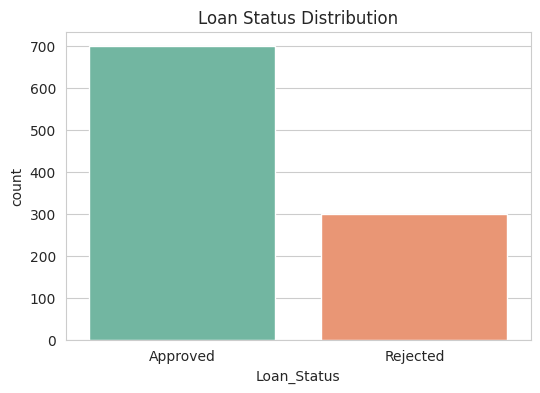

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='Loan_Status', hue='Loan_Status', palette='Set2', legend=False, ax=ax)
ax.set_title('Loan Status Distribution')
plt.show()


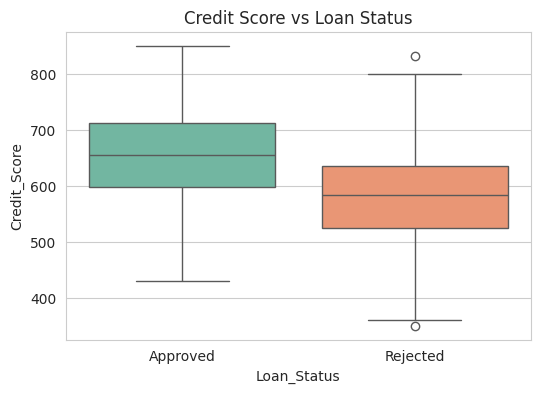

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Loan_Status', y='Credit_Score', hue='Loan_Status', palette='Set2', legend=False, ax=ax)
ax.set_title('Credit Score vs Loan Status')
plt.show()


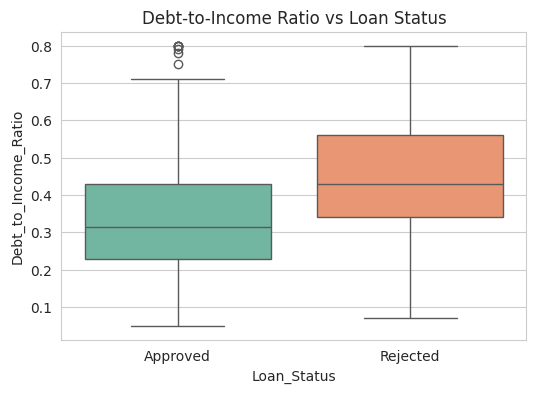

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Loan_Status', y='Debt_to_Income_Ratio', hue='Loan_Status', palette='Set2', legend=False, ax=ax)
ax.set_title('Debt-to-Income Ratio vs Loan Status')
plt.show()


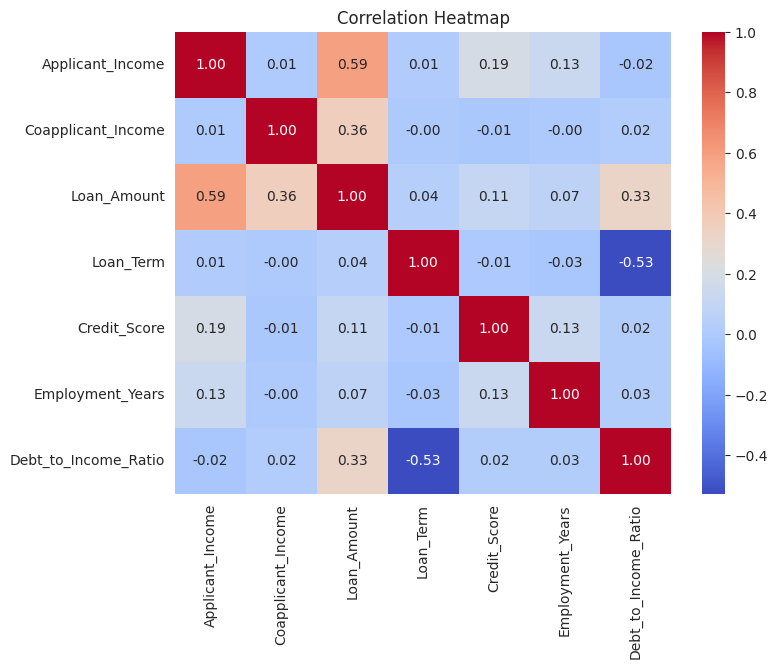

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[['Applicant_Income','Coapplicant_Income','Loan_Amount','Loan_Term',
                 'Credit_Score','Employment_Years','Debt_to_Income_Ratio']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()


> For the complete set of 12 EDA visualizations (saved as PNG files), run `src/eda.py` — 
> they are also saved automatically to `results/eda/`.

## 3. Preprocessing Pipeline

In [9]:
from data_preprocessing import load_and_split_data, build_preprocessing_pipeline

X_train, X_test, y_train, y_test = load_and_split_data()

preprocessor = build_preprocessing_pipeline()
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('Train shape:', X_train_transformed.shape)
print('Test shape:', X_test_transformed.shape)


Train shape: (800, 9)
Test shape: (200, 9)


## 4. Train Classification Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
}

POSITIVE_LABEL = 'Approved'
results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    y_proba = model.predict_proba(X_test_transformed)[:, list(model.classes_).index(POSITIVE_LABEL)]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        'Recall': recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        'F1_Score': f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        'ROC_AUC': roc_auc_score((y_test == POSITIVE_LABEL).astype(int), y_proba),
    }
    fitted_models[name] = model

results_df = pd.DataFrame(results).T.round(4)
results_df


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Logistic Regression,0.850,0.8767,0.9143,0.8951,0.9096
Decision Tree,0.775,0.8417,0.8357,0.8387,0.7730
Random Forest,0.830,0.8487,0.9214,0.8836,0.8668
K-Nearest Neighbors,0.830,0.8354,0.9429,0.8859,0.8517


## 5. Compare Models & Select the Best

In [11]:
composite_score = 0.5 * results_df['F1_Score'] + 0.5 * results_df['ROC_AUC']
best_model_name = composite_score.idxmax()
best_model = fitted_models[best_model_name]

print('Best model (by 0.5*F1 + 0.5*ROC-AUC):', best_model_name)
results_df.loc[[best_model_name]]


Best model (by 0.5*F1 + 0.5*ROC-AUC): Logistic Regression


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
Logistic Regression,0.85,0.8767,0.9143,0.8951,0.9096


**Why not pick the highest-accuracy model automatically?**
Accuracy can be misleading on a 70/30 imbalanced target — a model could score well by
favoring the majority class (`Approved`) while missing risky applicants. Combining
**F1 Score** (balances precision & recall on the Approved class) with **ROC-AUC**
(ranking quality across all thresholds) gives a fairer picture of real-world lending risk.

## 6. Confusion Matrix for the Best Model

              precision    recall  f1-score   support

    Rejected       0.78      0.70      0.74        60
    Approved       0.88      0.91      0.90       140

    accuracy                           0.85       200
   macro avg       0.83      0.81      0.82       200
weighted avg       0.85      0.85      0.85       200



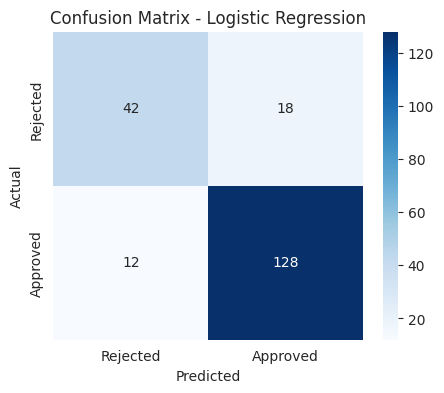

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_best = best_model.predict(X_test_transformed)
print(classification_report(y_test, y_pred_best, labels=['Rejected','Approved']))

cm = confusion_matrix(y_test, y_pred_best, labels=['Rejected','Approved'])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()


## 7. Save the Best Model & Preprocessing Pipeline

In [13]:
import joblib

MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(MODELS_DIR, 'loan_approval_model.pkl'))
joblib.dump(preprocessor, os.path.join(MODELS_DIR, 'preprocessing_pipeline.pkl'))

print('Model and pipeline saved to', MODELS_DIR)


Model and pipeline saved to ../models


## 8. Demonstrate a Prediction

In [14]:
from predict import predict_loan

result = predict_loan(
    applicant_income=85000,
    coapplicant_income=25000,
    loan_amount=1200000,
    loan_term=240,
    credit_score=740,
    employment_years=8,
    debt_to_income_ratio=0.28,
    property_area='Semiurban',
)
result


{'Loan_Status': 'Approved',
 'Approval_Probability': 99.75,
 'Rejection_Probability': 0.25}

## Summary

- Trained and compared 4 classifiers: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors
- Selected the best model using a balanced F1/ROC-AUC score, not accuracy alone
- Saved the model and preprocessing pipeline for reuse in `src/predict.py` and the Flask web app
- The same artifacts power the web application in `app/app.py`
